In [1]:
!pip install pyspark

from pyspark.sql import SparkSession

# Memulai Spark Session
spark = SparkSession.builder \
    .appName("BigData_Health_Analysis") \
    .getOrCreate()

print("Spark Session Berhasil Dibuat!")

Spark Session Berhasil Dibuat!


In [2]:
file_path = 'cardio_train.csv'

# Load data CSV yang udah lu upload
df = spark.read.csv(file_path, header=True, inferSchema=True, sep=';')

print(f"Jumlah Data: {df.count()} baris")
df.show(5)

Jumlah Data: 70000 baris
+---+-----+------+------+------+-----+-----+-----------+----+-----+----+------+------+
| id|  age|gender|height|weight|ap_hi|ap_lo|cholesterol|gluc|smoke|alco|active|cardio|
+---+-----+------+------+------+-----+-----+-----------+----+-----+----+------+------+
|  0|18393|     2|   168|  62.0|  110|   80|          1|   1|    0|   0|     1|     0|
|  1|20228|     1|   156|  85.0|  140|   90|          3|   1|    0|   0|     1|     1|
|  2|18857|     1|   165|  64.0|  130|   70|          3|   1|    0|   0|     0|     1|
|  3|17623|     2|   169|  82.0|  150|  100|          1|   1|    0|   0|     1|     1|
|  4|17474|     1|   156|  56.0|  100|   60|          1|   1|    0|   0|     0|     0|
+---+-----+------+------+------+-----+-----+-----------+----+-----+----+------+------+
only showing top 5 rows


In [3]:
from pyspark.ml.feature import VectorAssembler

# Buang kolom ID karena nggak penting buat medis
df = df.drop('id')

# Kumpulkan semua fitur kecuali kolom target ('cardio')
feature_columns = [col for col in df.columns if col != 'cardio']

# Satukan jadi vektor buat dibaca AI
assembler = VectorAssembler(inputCols=feature_columns, outputCol='features')
data_prepared = assembler.transform(df)

# Bagi data: 80% buat belajar, 20% buat ujian
train_data, test_data = data_prepared.randomSplit([0.8, 0.2], seed=42)
print("Data siap ditraining!")

Data siap ditraining!


In [4]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Bikin AI-nya
rf = RandomForestClassifier(featuresCol='features', labelCol='cardio', numTrees=100, seed=42)

print("Mulai training AI, tunggu bentar...")
rf_model = rf.fit(train_data)

# Test akurasinya
predictions = rf_model.transform(test_data)
evaluator = MulticlassClassificationEvaluator(labelCol='cardio', predictionCol='prediction', metricName='accuracy')
accuracy = evaluator.evaluate(predictions)

print(f"Akurasi Model Random Forest: {accuracy * 100:.2f}%")

Mulai training AI, tunggu bentar...
Akurasi Model Random Forest: 72.73%


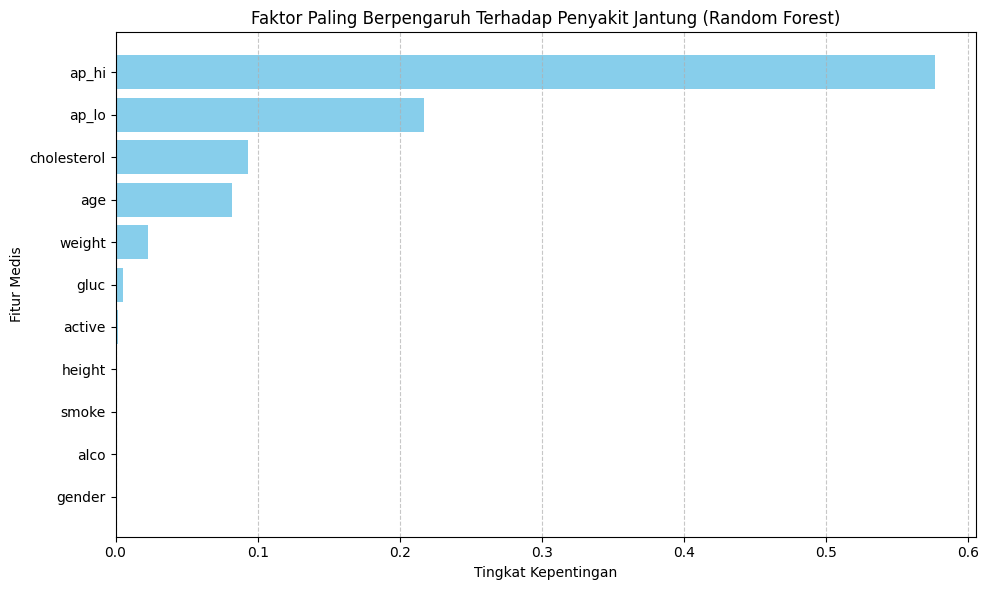

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Ambil data faktor apa yang paling bikin sakit jantung
importances = rf_model.featureImportances.toArray()
feature_imp_df = pd.DataFrame({
    'Fitur': feature_columns,
    'Pentingnya_Fitur': importances
}).sort_values(by='Pentingnya_Fitur', ascending=False)

# Bikin gambarnya
plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['Fitur'], feature_imp_df['Pentingnya_Fitur'], color='skyblue')
plt.gca().invert_yaxis()
plt.title('Faktor Paling Berpengaruh Terhadap Penyakit Jantung (Random Forest)')
plt.xlabel('Tingkat Kepentingan')
plt.ylabel('Fitur Medis')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()